# Posterior Associations - General Analysis

This notebook analyzes posterior associations from clustering results.

For merger history analysis, see the separate `merger_histories.ipynb` notebook.

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os
import sys
sys.path.insert(0, '..')

from backend.io import load_hdbscan_clusters_from_hdf5

## Configuration

Specify the path to the posterior association catalog HDF5 file below.

In [22]:
# ============================================================
# CONFIGURATION - Edit these parameters
# ============================================================

# Path to the posterior association catalog (HDF5 file)
CATALOG_PATH = "../output/dbscan_clusters_eps_2.75_ms_10.h5"

# Quality selection: "Raw", "Fiducial", or "Strict"
#   Raw:      No cuts (all clusters)
#   Fiducial: ambiguity_rate <= 0.05, n_members >= 20
#   Strict:   Fiducial + sigma_R <= 2.5 Mpc, sigma_log_M <= 0.25 dex
QUALITY_SELECTION = "Fiducial"

# Plotting style
try:
    from pymanticore.analysis.matplotlib import get_mplstyle_path
    mnras_style = "mnras"
    USE_MNRAS_STYLE = True
except ImportError:
    USE_MNRAS_STYLE = False
    print("pymanticore not found, using default matplotlib style")

# ============================================================
        
print(f"Catalog: {CATALOG_PATH}")
print(f"Quality selection: {QUALITY_SELECTION}")

Catalog: ../output/dbscan_clusters_eps_2.75_ms_10.h5
Quality selection: Fiducial


## Load Data

Load cluster data from the HDF5 catalog and apply quality selection cuts.

In [ ]:
# Load clusters using the backend IO function
clusters_raw, assignments, metadata = load_hdbscan_clusters_from_hdf5(
    os.path.dirname(CATALOG_PATH),
    os.path.basename(CATALOG_PATH),
    min_existence_prob=0.0,
    load_members=True
)

print(f"Loaded {len(clusters_raw)} clusters (raw)")

# Load quality selection criteria from shared YAML file
import yaml

with open('selection_cuts.yaml', 'r') as f:
    SELECTION_CUTS = yaml.safe_load(f)

# Convert YAML format [min, max] to tuple format (min, max)
for selection_name, cuts in SELECTION_CUTS.items():
    if cuts:  # Skip empty dicts (like 'Raw')
        SELECTION_CUTS[selection_name] = {k: tuple(v) for k, v in cuts.items()}

def apply_quality_cuts(clusters_list, selection_name):
    """Apply quality cuts to filter clusters."""
    if selection_name not in SELECTION_CUTS:
        raise ValueError(f"Unknown selection: {selection_name}. Choose from {list(SELECTION_CUTS.keys())}")
    
    cuts = SELECTION_CUTS[selection_name]
    if not cuts:
        return clusters_list  # Raw - no filtering
    
    filtered = []
    for c in clusters_list:
        # Extract values for comparison
        values = {
            'ambiguity_rate': c.get('ambiguity_rate', 0),
            'n_members': c.get('n_members', 0),
            'sigma_R': np.linalg.norm(c.get('position_std', [0, 0, 0])),
            'sigma_log_M': c.get('log10_m200_mass_std', 0),
            'center_xyz': c.get('center_xyz', [0,0,0]),
        }
        
        # Check all cuts
        passes = True
        for key, (lo, hi) in cuts.items():
            val = values.get(key, 0)
            if lo is not None and val < lo:
                passes = False
                break
            if hi is not None and val > hi:
                passes = False
                break
        
        if passes:
            filtered.append(c)
    
    return filtered

# Apply the selected quality cuts
clusters = apply_quality_cuts(clusters_raw, QUALITY_SELECTION)
clusters_available = len(clusters) > 0

print(f"After '{QUALITY_SELECTION}' cuts: {len(clusters)} clusters ({100*len(clusters)/len(clusters_raw):.1f}%)")

if clusters_available:
    print(f"Cluster size range: {min(c['n_members'] for c in clusters)} - {max(c['n_members'] for c in clusters)}")
    print(f"Mass range: {min(c['mean_m200_mass'] for c in clusters):.2e} - {max(c['mean_m200_mass'] for c in clusters):.2e} Msol")

## Plot 1: Example Halo Groupings

Shows 2D projections of halo members for selected clusters, demonstrating the spatial grouping of halos within each association.

In [4]:
def plot_multi_cluster_diagnostic(cluster_ids, window_size=15.0):
    if not clusters_available or len(clusters) == 0:
        print("No clusters available for diagnostic plot")
        return
    
    if len(cluster_ids) != 2:
        print("Function requires exactly 2 cluster IDs")
        return
    
    # Find target clusters
    target_clusters = []
    for cluster_id in cluster_ids:
        target_cluster = None
        for cluster in clusters:
            if cluster['cluster_id'] == cluster_id:
                target_cluster = cluster
                break
        if target_cluster is None:
            print(f"Cluster ID {cluster_id} not found")
            return
        target_clusters.append(target_cluster)
    
    # Get style context
    if USE_MNRAS_STYLE:
        style_context = plt.style.context(get_mplstyle_path(mnras_style))
    else:
        from contextlib import nullcontext
        style_context = nullcontext()
    
    with style_context:
        fig, axes = plt.subplots(3, 2, figsize=(4., 5.5))
        
        projections = [
            (0, 1, 'X', 'Y'),
            (0, 2, 'X', 'Z'), 
            (1, 2, 'Y', 'Z')
        ]
        
        symbols = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
        
        # Collect all unique cluster IDs across both target clusters
        all_unique_cluster_ids = set()
        for target_cluster in target_clusters:
            target_cluster_center = target_cluster['center_xyz']
            
            # Find clusters whose centroids are within the window
            for cluster in clusters:
                cluster_center = cluster['center_xyz']
                distance_to_target = np.linalg.norm(cluster_center - target_cluster_center)
                if distance_to_target <= window_size:
                    all_unique_cluster_ids.add(cluster['cluster_id'])
        
        # Create global color and symbol map for all unique cluster IDs
        all_unique_cluster_ids = sorted(list(all_unique_cluster_ids))
        colors = plt.cm.tab10(np.linspace(0, 1, len(all_unique_cluster_ids)))
        global_color_map = {cluster_id: colors[i] for i, cluster_id in enumerate(all_unique_cluster_ids)}
        global_symbol_map = {cluster_id: symbols[i % len(symbols)] for i, cluster_id in enumerate(all_unique_cluster_ids)}
        
        for proj_idx, (dim1, dim2, label1, label2) in enumerate(projections):
            for cluster_idx, target_cluster in enumerate(target_clusters):
                target_cluster_center = target_cluster['center_xyz']
                target_cluster_id = target_cluster['cluster_id']
                
                ax = axes[proj_idx, cluster_idx]
                
                # Find clusters whose centroids are within the window
                clusters_in_window = []
                for cluster in clusters:
                    cluster_center = cluster['center_xyz']
                    distance_to_target = np.linalg.norm(cluster_center - target_cluster_center)
                    if distance_to_target <= window_size:
                        clusters_in_window.append(cluster)
                
                # Only plot members from clusters whose centroids are in the window
                nearby_positions = []
                nearby_cluster_labels = []
                
                for cluster in clusters_in_window:
                    # Try different position keys depending on format
                    if 'member_data' in cluster:
                        if 'positions' in cluster['member_data']:
                            positions = cluster['member_data']['positions']
                        elif 'BoundSubhalo/CentreOfMass' in cluster['member_data']:
                            positions = cluster['member_data']['BoundSubhalo/CentreOfMass']
                        else:
                            # Skip if no position data
                            continue
                    else:
                        continue
                    
                    cluster_id_val = cluster['cluster_id']
                    nearby_positions.extend(positions)
                    nearby_cluster_labels.extend([cluster_id_val] * len(positions))
                
                nearby_positions = np.array(nearby_positions)
                nearby_cluster_labels = np.array(nearby_cluster_labels)
                
                # Calculate optimized axis limits for this subplot
                if len(nearby_positions) > 0:
                    min_pos = np.min(nearby_positions, axis=0)
                    max_pos = np.max(nearby_positions, axis=0)
                    ranges = max_pos - min_pos
                    centers = (min_pos + max_pos) / 2
                    max_range = np.max(ranges)
                    padding = max_range * 0.05
                else:
                    centers = target_cluster_center
                    max_range = 10.0
                    padding = 0.5
                
                unique_labels = np.unique(nearby_cluster_labels)
                
                legend_handles = []
                
                # Offset for centering (adjust if needed based on your data)
                offset = 500
                
                for label in unique_labels:
                    mask = nearby_cluster_labels == label
                    color = global_color_map[label]
                    symbol = global_symbol_map[label]
                    scatter = ax.scatter(nearby_positions[mask, dim1] - offset, 
                                        nearby_positions[mask, dim2] - offset, 
                                        c=[color], s=10, alpha=0.6, marker=symbol, 
                                        edgecolor="black", lw=0.2)
                    
                    legend_handles.append(plt.Line2D([0], [0], marker=symbol, color='w', 
                                                     markerfacecolor=color, markersize=8, 
                                                     label=f'Association {label}', alpha=0.6))
                
                # Plot cluster centroids and annotations
                for cluster in clusters_in_window:
                    cluster_center = cluster['center_xyz'] - offset
                    cluster_id_val = cluster['cluster_id']
                    color = global_color_map[cluster_id_val]
                    
                    # Mark centroid
                    ax.scatter(cluster_center[dim1], cluster_center[dim2], 
                              c='red', s=100, marker='*', edgecolors='black', linewidth=0.5)
                    
                    # Add position std circle around centroid
                    position_std = np.linalg.norm(cluster['position_std'])
                    circle = plt.Circle((cluster_center[dim1], cluster_center[dim2]), 
                                       position_std, fill=False, color=color, 
                                       linestyle='-', linewidth=1, alpha=0.7)
                    ax.add_patch(circle)

                ax.set_xlabel(f'{label1} (Mpc)')
                ax.set_ylabel(f'{label2} (Mpc)')
                
                ax.set_aspect('equal')
                
                # Set optimized square axis limits
                center_2d = centers[[dim1, dim2]]
                half_range = max_range / 2 + padding
                ax.set_xlim((center_2d[0] - offset) - half_range, (center_2d[0] - offset) + half_range)
                ax.set_ylim((center_2d[1] - offset) - half_range, (center_2d[1] - offset) + half_range)
                
                # Add legend only to bottom row
                if cluster_idx == 0:
                    if proj_idx == 1 and legend_handles:
                        ax.legend(handles=legend_handles, loc="lower left", fontsize=6)
                else:
                    if proj_idx == 0 and legend_handles:
                        ax.legend(handles=legend_handles, loc="upper right", fontsize=6)
        
        plt.tight_layout(pad=0.1)
        plt.subplots_adjust(hspace=0.3, wspace=0.3)
        plt.savefig("./plots/example_halo_groupings.pdf")
        plt.show()

Top 20 cluster IDs by size: [0, 2, 4, 5, 6, 12, 14, 16, 17, 18, 19, 20, 22, 25, 28, 30, 31, 37, 43, 44]

Plotting clusters: [4, 30]


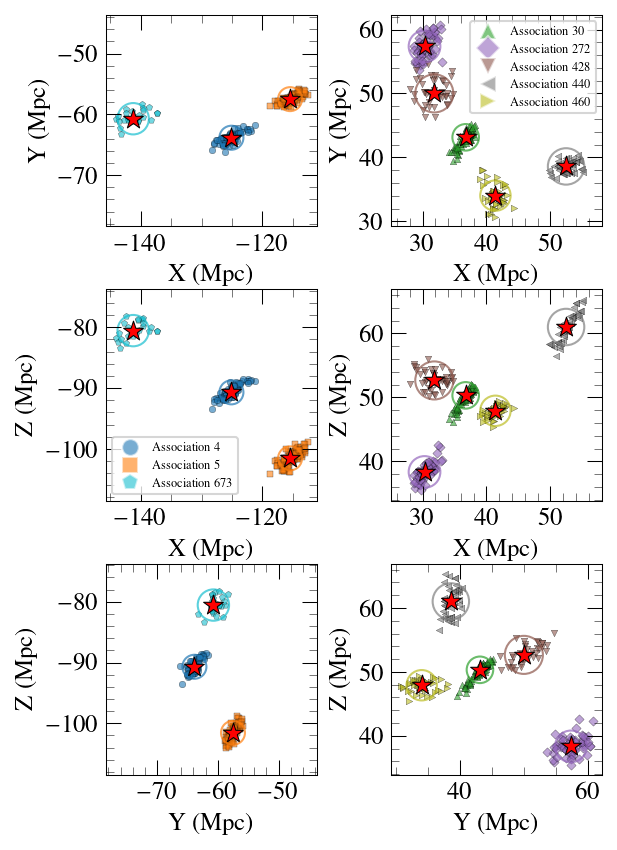

In [5]:
#### Select two cluster IDs to plot (modify these based on your data)
# Choose clusters with interesting groupings
if clusters_available:
    # Get cluster IDs sorted by size
    sorted_clusters = sorted(clusters, key=lambda c: c['n_members'], reverse=True)
    available_ids = [c['cluster_id'] for c in sorted_clusters[:20]]
    print(f"Top 20 cluster IDs by size: {available_ids}")
    
    # Default to first two large clusters
    cluster_ids_to_plot = [4,30] # available_ids[:2]
    print(f"\nPlotting clusters: {cluster_ids_to_plot}")
    
    plot_multi_cluster_diagnostic(cluster_ids_to_plot, window_size=20)

## Plot 2: Position Standard Deviation and Axis Ratio vs Mass

Shows how the spatial scatter (position_std) and shape (axis ratio b/a) of associations vary with their mean mass, binned by association size.

In [6]:
def plot_position_std_and_axis_ratio_vs_mass(size_bin_edges):
    if not clusters_available or len(clusters) == 0:
        print("No clusters available")
        return
    
    cluster_masses = np.array([cluster['mean_m200_mass'] for cluster in clusters])
    position_stds = np.array([np.linalg.norm(cluster['position_std']) for cluster in clusters])
    cluster_sizes = np.array([cluster['n_members'] for cluster in clusters])
    axis_ratio_ba = np.array([cluster.get('axis_ratio_ba', np.nan) for cluster in clusters])
    
    # Create masks for size bins using bin edges
    masks = []
    labels = []
    for i in range(len(size_bin_edges) - 1):
        mask = (cluster_sizes >= size_bin_edges[i]) & (cluster_sizes < size_bin_edges[i+1])
        labels.append(f'{size_bin_edges[i]}-{size_bin_edges[i+1]}')
        masks.append(mask)
    
    colors = plt.cm.Set1(np.linspace(0, 1, len(masks)))
    
    # Get style context
    if USE_MNRAS_STYLE:
        style_context = plt.style.context(get_mplstyle_path(mnras_style))
    else:
        from contextlib import nullcontext
        style_context = nullcontext()

    with style_context:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4), sharex=True)
        
        # Create log-spaced mass bins
        mass_bins = np.logspace(14,16,20)
        
        # Top panel: Position STD
        for i, (mask, label, color) in enumerate(zip(masks, labels, colors)):
            if np.sum(mask) == 0:
                continue
                
            masses_subset = cluster_masses[mask]
            stds_subset = position_stds[mask]
            
            # Bin the data
            bin_indices = np.digitize(masses_subset, mass_bins)
            
            medians = []
            p25 = []
            p75 = []
            bin_centers = []
            
            for j in range(1, len(mass_bins)):
                bin_mask = bin_indices == j
                if np.sum(bin_mask) >= 3:  # Need at least 3 points for statistics
                    bin_stds = stds_subset[bin_mask]
                    medians.append(np.median(bin_stds))
                    p25.append(np.percentile(bin_stds, 25))
                    p75.append(np.percentile(bin_stds, 75))
                    bin_centers.append(np.sqrt(mass_bins[j-1] * mass_bins[j]))
            
            if len(medians) > 0:
                bin_centers = np.array(bin_centers)
                medians = np.array(medians)
                p25 = np.array(p25)
                p75 = np.array(p75)
                
                ax1.plot(bin_centers, medians, '-o', color=color, label=label, linewidth=1, markersize=3)
                ax1.fill_between(bin_centers, p25, p75, color=color, alpha=0.2, lw=None)
        
        ax1.set_ylabel("Association positional\n" + r"standard deviation $\sigma_{R}$ [Mpc]",
                      fontsize=10)
        ax1.set_xscale('log')
        ax1.legend(title=r"Association $N_{\mathrm{members}}$")
        
        # Bottom panel: Axis Ratio b/a
        for i, (mask, label, color) in enumerate(zip(masks, labels, colors)):
            if np.sum(mask) == 0:
                continue
                
            masses_subset = cluster_masses[mask]
            axis_ratio_subset = axis_ratio_ba[mask]
            
            # Filter out NaN values
            finite_mask = np.isfinite(axis_ratio_subset)
            if np.sum(finite_mask) == 0:
                continue
                
            masses_subset = masses_subset[finite_mask]
            axis_ratio_subset = axis_ratio_subset[finite_mask]
            
            # Bin the data
            bin_indices = np.digitize(masses_subset, mass_bins)
            
            medians = []
            p25 = []
            p75 = []
            bin_centers = []
            
            for j in range(1, len(mass_bins)):
                bin_mask = bin_indices == j
                if np.sum(bin_mask) >= 3:  # Need at least 3 points for statistics
                    bin_ratios = axis_ratio_subset[bin_mask]
                    medians.append(np.median(bin_ratios))
                    p25.append(np.percentile(bin_ratios, 25))
                    p75.append(np.percentile(bin_ratios, 75))
                    bin_centers.append(np.sqrt(mass_bins[j-1] * mass_bins[j]))
            
            if len(medians) > 0:
                bin_centers = np.array(bin_centers)
                medians = np.array(medians)
                p25 = np.array(p25)
                p75 = np.array(p75)
                
                ax2.plot(bin_centers, medians, '-o', color=color, linewidth=1, markersize=3)
                ax2.fill_between(bin_centers, p25, p75, color=color, alpha=0.2, lw=None)
        
        ax2.set_xlabel(r'Association mean mass $\langle M_{\mathrm{200}} \rangle$ [M$_{\odot}$]')
        ax2.set_ylabel(r'Association axis Ratio $b/a$', fontsize=10)
        ax2.set_xscale('log')
        ax2.set_xlim(1e14, 0.8e15)
        
        plt.tight_layout(pad=0.1)
        plt.savefig("./plots/position_std_and_axis_ratio_vs_mass.pdf")
        plt.show()

Cluster size range: 20 - 80
Cluster size quartiles: [25. 34. 47.]

Using size bins: [20, 40, 80]


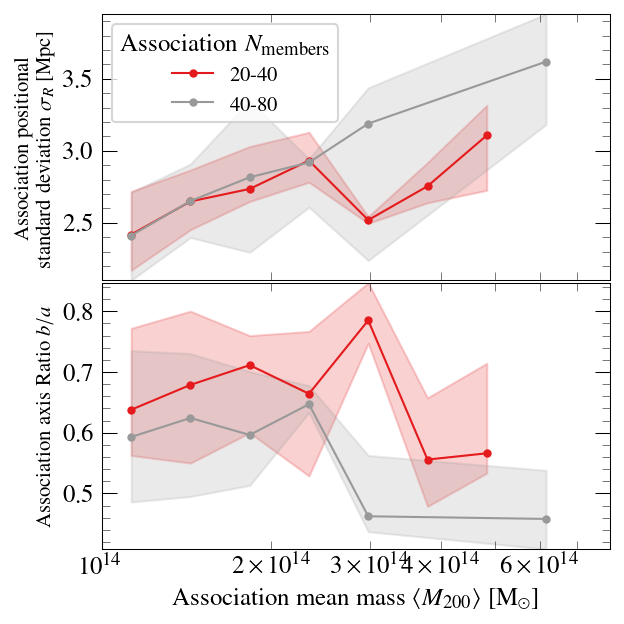

In [7]:
# Define size bins and create plot
if clusters_available:
    # Check the range of cluster sizes to set appropriate bins
    sizes = [c['n_members'] for c in clusters]
    print(f"Cluster size range: {min(sizes)} - {max(sizes)}")
    print(f"Cluster size quartiles: {np.percentile(sizes, [25, 50, 75])}")
    
    # Define bin edges (modify based on your data)
    size_bin_edges = [20, 40, 80]
    print(f"\nUsing size bins: {size_bin_edges}")
    
    plot_position_std_and_axis_ratio_vs_mass(size_bin_edges)

## Plot 3: Posterior Positions

Shows all association member positions in XY projection and on-sky (Mollweide) projection.

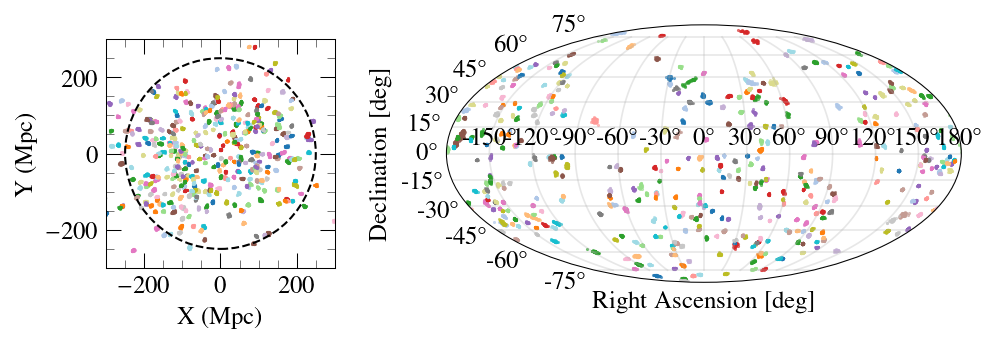

In [8]:
import random

def plot_posterior_positions():
    if not clusters_available or len(clusters) == 0:
        print("No clusters available")
        return
    
    # Get style context
    if USE_MNRAS_STYLE:
        style_context = plt.style.context(get_mplstyle_path(mnras_style))
    else:
        from contextlib import nullcontext
        style_context = nullcontext()
    
    with style_context:
        fig = plt.figure(figsize=(6.5, 3.0))
        gs = fig.add_gridspec(1, 2, width_ratios=[1, 2.25])

        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1], projection='mollweide')

        # Assign random colors to each cluster
        tab20_colors = plt.cm.tab20(np.linspace(0, 1, 20))
        random.seed(42)
        assigned_colors = random.choices(tab20_colors, k=len(clusters))

        for i, cluster in enumerate(clusters):
            color = assigned_colors[i]
            
            # Get positions - try different keys depending on format
            if 'member_data' not in cluster:
                continue
            
            member_data = cluster['member_data']
            
            # Get XYZ positions
            if 'positions' in member_data:
                positions = member_data['positions']
            elif 'BoundSubhalo/CentreOfMass' in member_data:
                positions = member_data['BoundSubhalo/CentreOfMass']
            else:
                continue
            
            # Plot XY projection (offset by 500 to center on observer)
            ax1.scatter(positions[:, 0] - 500, positions[:, 1] - 500, 
                       c=[color], s=1, alpha=0.7, marker=".", rasterized=True)

            # Get RA/Dec for Mollweide
            if 'ra' in member_data and 'dec' in member_data:
                ra = np.asarray(member_data['ra'])
                dec = np.asarray(member_data['dec'])
            else:
                # Compute from positions if not available
                observer = np.array([500, 500, 500])
                rel_pos = positions - observer
                dist = np.linalg.norm(rel_pos, axis=1)
                ra = np.degrees(np.arctan2(rel_pos[:, 1], rel_pos[:, 0]))
                dec = np.degrees(np.arcsin(rel_pos[:, 2] / dist))
            
            # Mollweide expects longitude (ra) in [-pi, pi] and latitude (dec) in radians
            ra_wrapped = np.where(ra > 180, ra - 360, ra)  # wrap to [-180, 180]
            ra_rad = np.radians(ra_wrapped)
            dec_rad = np.radians(dec)
            ax2.scatter(ra_rad, dec_rad, c=[color], s=1, alpha=0.7, marker=".", rasterized=True)

        # 2D plot formatting
        ax1.set_xlabel('X (Mpc)')
        ax1.set_ylabel('Y (Mpc)')
        ax1.set_ylim(-300, 300)
        ax1.set_xlim(-300, 300)
        circle = plt.Circle((0, 0), 250, fill=False, color='black', linestyle='--', linewidth=1)
        ax1.add_patch(circle)
        ax1.set_aspect('equal')

        # Mollweide formatting
        ax2.grid(True, alpha=0.3)
        tick_labels = np.arange(-150, 181, 30)
        ax2.set_xticks(np.radians(tick_labels))
        ax2.set_xticklabels([f"{tl}°" for tl in tick_labels])
        ax2.set_xlabel('Right Ascension [deg]')
        ax2.set_ylabel('Declination [deg]')

        plt.tight_layout(pad=0.1)
        plt.subplots_adjust(wspace=0.3)
        plt.savefig("./plots/posterior_positions.pdf")
        plt.show()

# Create the plot
plot_posterior_positions()

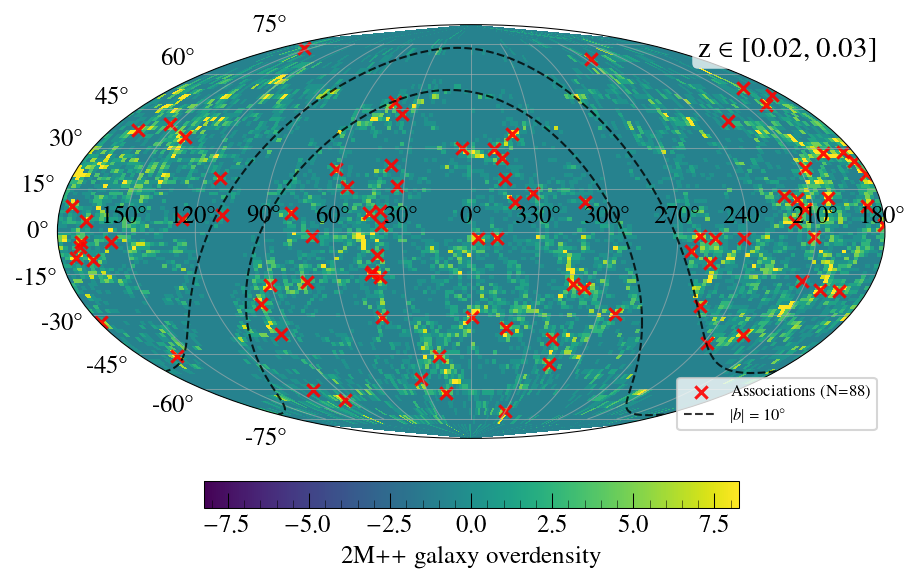

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

import numpy as np

def plot_wrapped_line(ax, lon, lat, *, jump=np.pi, **plot_kwargs):
    """Plot a curve on a [-pi, pi] map without drawing seam-bridging chords.
    If 'label' is provided, it will be applied only once (first segment).
    """
    lon = np.asarray(lon)
    lat = np.asarray(lat)

    # Pull label (if any) so we can apply it only once
    label = plot_kwargs.pop("label", None)

    breaks = np.where(np.abs(np.diff(lon)) > jump)[0] + 1
    segments = np.split(np.arange(lon.size), breaks)

    first = True
    for seg in segments:
        if seg.size < 2:
            continue
        if first and label is not None:
            ax.plot(lon[seg], lat[seg], label=label, **plot_kwargs)
            first = False
        else:
            ax.plot(lon[seg], lat[seg], **plot_kwargs)


def ra_to_mollweide_lon(ra_rad, *, center_ra_deg=0.0, flip="astro"):
    """
    Convert RA [rad] to Mollweide 'lon' in [-pi, pi] for matplotlib.

    Parameters
    ----------
    center_ra_deg : float
        RA (deg) that should appear at the center of the map.
        (healpy-like 'rot' around the z axis)
    flip : {"astro","geo"}
        astro: longitude increases to the left (common sky-map convention)
        geo:   longitude increases to the right (matplotlib-native)

    Returns
    -------
    lon_rad in [-pi, pi]
    """
    ra0 = np.deg2rad(center_ra_deg)
    lon = (ra_rad - ra0 + np.pi) % (2*np.pi) - np.pi  # wrap to [-pi, pi]
    if flip.lower() == "astro":
        lon = -lon
    elif flip.lower() != "geo":
        raise ValueError("flip must be 'astro' or 'geo'")
    return lon

# Get style context
if USE_MNRAS_STYLE:
    style_context = plt.style.context(get_mplstyle_path(mnras_style))
else:
    from contextlib import nullcontext
    style_context = nullcontext()
    
# -----------------------
# Inputs
# -----------------------
path = "/cosma7/data/dp004/rttw52/Manticore/catalog_data/catalogs/catalogs_ascii/2mpp_manticore_cmb_frame.txt"

# Redshift slice to display (same slice used for galaxies + clusters)
zmin, zmax = 0.02, 0.03   # set to None to disable a bound

# Allow clusters slightly beyond slice edges (in redshift units)
cluster_z_buffer = 0.001  # e.g. 0.003; set to 0.0 for no buffer

# Coarse binning (acts like smoothing)
nlon, nmu = 180, 90       # try 120/60, 180/90, 240/120, ...

# Overdensity color scaling
clim_percentile = 99.0    # try 95.0 for more contrast

# Cluster->z via Hubble law
H0 = 68.1                 # km/s/Mpc
c_kms = 299792.458        # km/s
observer_xyz = np.array([500.0, 500.0, 500.0])  # same units as cluster_xyz (assumed Mpc)

# Galactic-plane outline sampling
l = np.linspace(0, 360, 2000) * u.deg

# -----------------------
# Load galaxy catalog + slice
# -----------------------
data = np.genfromtxt(path, comments="#")
if data.ndim == 1:
    data = data[None, :]
if data.shape[1] < 4:
    raise ValueError(f"Expected >=4 columns (id, ra, dec, redshift...). Got shape {data.shape}.")

ra  = data[:, 1]   # radians
dec = data[:, 2]   # radians
zg  = data[:, 3]   # redshift

gmask = np.ones_like(zg, dtype=bool)
if zmin is not None:
    gmask &= (zg >= zmin)
if zmax is not None:
    gmask &= (zg <= zmax)

ra, dec, zg = ra[gmask], dec[gmask], zg[gmask]
if ra.size == 0:
    raise ValueError("No galaxies in the requested redshift slice.")

# Mollweide longitude in [-pi, pi], flip sign so RA increases to the left
lon = (ra + np.pi) % (2 * np.pi) - np.pi
lon = -lon
lat = dec

# -----------------------
# Make overdensity map in equal-area pixels (lon, mu=sin(lat))
# -----------------------
mu = np.sin(lat)

lon_edges = np.linspace(-np.pi, np.pi, nlon + 1)
mu_edges  = np.linspace(-1.0, 1.0, nmu + 1)

N, _, _ = np.histogram2d(lon, mu, bins=[lon_edges, mu_edges])
meanN = N.mean()
if meanN <= 0:
    raise ValueError("Mean count per pixel is zero (unexpected).")

delta = (N / meanN) - 1.0

# Convert mu-edges -> lat-edges for plotting
lat_edges = np.arcsin(np.clip(mu_edges, -1.0, 1.0))

v = np.nanpercentile(np.abs(delta), clim_percentile)
v = max(v, 1e-6)

# -----------------------
# Compute cluster RA/Dec and Hubble-law z, then slice and overlay
# Assumes `clusters` is a list of dicts, each with cluster['center_xyz'] (x,y,z).
# -----------------------
if "clusters" not in globals() or clusters is None or len(clusters) == 0:
    print("Warning: `clusters` not found / empty, plotting only the galaxy overdensity field.")
    cl_lon = np.array([])
    cl_lat = np.array([])
    cl_z   = np.array([])
else:
    xyz = np.array([c["center_xyz"] for c in clusters], dtype=float)  # (N,3)
    rvec = xyz - observer_xyz[None, :]
    dist = np.linalg.norm(rvec, axis=1)  # assumed Mpc
    cl_z = (H0 * dist) / c_kms           # z ~ v/c, v=H0*d

    # Spherical angles from line-of-sight vector
    x, y, zc = rvec[:, 0], rvec[:, 1], rvec[:, 2]
    ra_c = (np.arctan2(y, x) + 2*np.pi) % (2*np.pi)
    dec_c = np.arcsin(np.clip(zc / np.maximum(dist, 1e-30), -1.0, 1.0))

    cl_lon = (ra_c + np.pi) % (2 * np.pi) - np.pi
    cl_lon = -cl_lon
    cl_lat = dec_c

    # buffered redshift slice for clusters only
    zmin_c = (zmin - cluster_z_buffer) if (zmin is not None) else None
    zmax_c = (zmax + cluster_z_buffer) if (zmax is not None) else None

    cmask = np.ones_like(cl_z, dtype=bool)
    if zmin_c is not None:
        cmask &= (cl_z >= zmin_c)
    if zmax_c is not None:
        cmask &= (cl_z <= zmax_c)

    cl_lon, cl_lat, cl_z = cl_lon[cmask], cl_lat[cmask], cl_z[cmask]

# -----------------------
# Plot
# -----------------------
with style_context:
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111, projection="mollweide")
    
    pm = ax.pcolormesh(
        lon_edges, lat_edges, delta.T,
        shading="auto",
        vmin=-v, vmax=v,
        cmap="viridis"
    )
    
    # Overlay clusters (red x markers)
    if cl_lon.size:
        ax.scatter(
            cl_lon, cl_lat,
            s=35,
            marker="x",
            linewidths=1.5,
            color="red",
            alpha=0.9,
            label=f"Associations (N={cl_lon.size})"
        )
    
    # Galactic plane outline: |b| = 10 deg (label only once)
    for i, bdeg in enumerate([+10.0, -10.0]):
        gal = SkyCoord(
            l=l,
            b=np.full_like(l.value, bdeg) * u.deg,
            frame="galactic"
        )
        icrs = gal.icrs
        ra_gp = icrs.ra.to(u.rad).value
        dec_gp = icrs.dec.to(u.rad).value

        lon_gp = (ra_gp + np.pi) % (2 * np.pi) - np.pi
        lon_gp = -lon_gp

        plot_wrapped_line(
            ax, lon_gp, dec_gp,
            color="black",
            linewidth=1.0,
            linestyle="--",
            alpha=0.8,
            label=r"$|b|=10^\circ$" if i == 0 else None
        )
    
    # Formatting
    ax.grid(True, linewidth=0.5, alpha=0.6)
    
    cb = plt.colorbar(pm, ax=ax, orientation="horizontal", pad=0.08, fraction=0.05)
    cb.set_label("2M++ galaxy overdensity")
    
    # Longitude ticks in degrees (map lon in [-180, 180], with RA-left convention already applied)
    xticks = np.deg2rad(np.arange(-150, 181, 30))
    ax.set_xticks(xticks)
    # Longitude ticks every 30 degrees in Mollweide lon [-180, 180]
    xtick_deg = np.arange(-150, 181, 30)
    ax.set_xticks(np.deg2rad(xtick_deg))
    
    # Custom labels:
    # left side (negative lon): 0 → 180
    # right side (positive lon): 360 → 180
    xtick_labels = []
    for d in xtick_deg:
        if d <= 0:
            label = abs(d)
        else:
            label = 360 - d
        xtick_labels.append(f"{int(label)}°")
    
    ax.set_xticklabels(xtick_labels)
    
    # No title; annotate redshift range in upper-right of axes
    z_text = r"z $\in$ " + f"[{zmin if zmin is not None else '-∞'}, {zmax if zmax is not None else '∞'}]"
    ax.text(
        0.99, 0.97, z_text,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.75, edgecolor="none")
    )
    
    ax.legend(loc="lower right", fontsize=8, frameon=True)
    
    plt.tight_layout(pad=0.1)
    plt.savefig("plots/2mpp_skymap_with_associations.pdf")
    plt.show()


## Associations of known clusters

In [10]:
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

# ---- Assumptions / required globals ----
# - `clusters` is a list of dicts
# - each cluster has a 3D Cartesian position at key "center_xyz" (or change below)
# - coordinates are in Mpc in the same frame as observer_xyz
# --------------------------------------

# Observer (Mpc)
observer_xyz = np.array([500.0, 500.0, 500.0])

# Hubble-law distance for converting known-object redshift -> Mpc (crude but consistent with earlier cells)
H0 = 68.1                 # km/s/Mpc
c_kms = 299792.458        # km/s
d_per_z = c_kms / H0      # Mpc per unit z

# Pick which cluster position field to use
CL_POS_KEY = "center_xyz"   # change to "cluster_xyz" if that's what you store

if "clusters" not in globals() or clusters is None or len(clusters) == 0:
    raise RuntimeError("`clusters` not found or empty. Run your clustering code first.")

# ---- Known objects (ICRS) ----
# (RA, Dec, z) values are standard approximate literature values.
known = [
    dict(name="Virgo Cluster (M87)", ra="12h30m49.4s", dec="+12d23m28s", z=0.0036),
    dict(name="Coma Cluster (Abell 1656)", ra="12h59m48.7s", dec="+27d58m50s", z=0.0231),
    dict(name="Perseus Cluster (Abell 426)", ra="03h19m48.1s", dec="+41d30m42s", z=0.0179),
]

# ---- Precompute cluster observer-centered vectors and derived (ra, dec, z_hubble) ----
xyz = np.array([c[CL_POS_KEY] for c in clusters], dtype=float)  # (N,3)
rvec = xyz - observer_xyz[None, :]
r = np.linalg.norm(rvec, axis=1)
r_safe = np.maximum(r, 1e-30)

# direction -> (ra, dec)
x, y, zc = rvec[:, 0], rvec[:, 1], rvec[:, 2]
cl_ra = (np.arctan2(y, x) + 2*np.pi) % (2*np.pi)           # rad
cl_dec = np.arcsin(np.clip(zc / r_safe, -1.0, 1.0))        # rad

# Hubble-law redshift proxy for clusters
cl_z = (H0 * r) / c_kms

# unit vectors
cl_u = rvec / r_safe[:, None]

def format_cluster_properties(cluster_dict, keys=None):
    """Pretty-print a cluster's properties."""
    if keys is None:
        # reasonable defaults; will only print those that exist
        keys = [
            "n_members",
            "mean_m200_mass",
            "axis_ratio_ba",
            "position_std",
            "velocity_dispersion",
            "center_xyz",
            "cluster_xyz",
        ]
    lines = []
    for k in keys:
        if k in cluster_dict:
            v = cluster_dict[k]
            if isinstance(v, (list, tuple, np.ndarray)):
                v = np.array(v)
                lines.append(f"  {k}: {np.array2string(v, precision=4, suppress_small=False)}")
            else:
                lines.append(f"  {k}: {v}")
    # If nothing matched, fall back to printing all keys (briefly)
    if not lines:
        for k in sorted(cluster_dict.keys()):
            v = cluster_dict[k]
            if isinstance(v, (list, tuple, np.ndarray)):
                v = np.array(v)
                lines.append(f"  {k}: {np.array2string(v, precision=4, suppress_small=False)}")
            else:
                lines.append(f"  {k}: {v}")
    return "\n".join(lines)

# ---- Match each known object to the closest cluster in 3D (observer-centered Mpc) ----
for obj in known:
    sc = SkyCoord(obj["ra"], obj["dec"], frame="icrs")
    ra0 = sc.ra.to(u.rad).value
    dec0 = sc.dec.to(u.rad).value

    # Hubble-law distance to object (Mpc)
    d0 = d_per_z * obj["z"]

    # object unit vector and 3D position in observer-centered coords
    u0 = np.array([np.cos(dec0) * np.cos(ra0), np.cos(dec0) * np.sin(ra0), np.sin(dec0)])
    r0 = d0 * u0

    # 3D separation
    d3 = np.linalg.norm(rvec - r0[None, :], axis=1)
    i = int(np.argmin(d3))

    # angular separation (deg)
    cosang = np.clip(np.dot(cl_u[i], u0), -1.0, 1.0)
    ang = np.degrees(np.arccos(cosang))

    # report
    print(f"\n=== {obj['name']} ===")
    print(f"Known object: RA={sc.ra.to_string(unit=u.hour, sep=':')}, Dec={sc.dec.to_string(unit=u.deg, sep=':')}, z≈{obj['z']:.4f}, d≈{d0:.2f} Mpc (Hubble-law)")
    print(f"Closest cluster index: {i}")
    print(f"3D separation: {d3[i]:.2f} Mpc")
    print(f"Angular separation: {ang:.2f} deg")
    print(f"Cluster: RA={np.degrees(cl_ra[i]):.3f} deg, Dec={np.degrees(cl_dec[i]):.3f} deg, z_hubble≈{cl_z[i]:.4f}, d≈{r[i]:.2f} Mpc")
    print("Cluster properties:")
    print(format_cluster_properties(clusters[i]))



=== Virgo Cluster (M87) ===
Known object: RA=12:30:49.4, Dec=12:23:28, z≈0.0036, d≈15.85 Mpc (Hubble-law)
Closest cluster index: 11
3D separation: 3.24 Mpc
Angular separation: 1.77 deg
Cluster: RA=188.777 deg, Dec=10.963 deg, z_hubble≈0.0043, d≈19.04 Mpc
Cluster properties:
  n_members: 80
  mean_m200_mass: 388944017489920.0
  axis_ratio_ba: 0.38282778701875203
  position_std: [1.2558 0.344  0.5369]
  center_xyz: [481.5251 497.1476 503.6211]

=== Coma Cluster (Abell 1656) ===
Known object: RA=12:59:48.7, Dec=27:58:50, z≈0.0231, d≈101.69 Mpc (Hubble-law)
Closest cluster index: 5
3D separation: 4.41 Mpc
Angular separation: 0.27 deg
Cluster: RA=194.653 deg, Dec=28.019 deg, z_hubble≈0.0241, d≈106.07 Mpc
Cluster properties:
  n_members: 80
  mean_m200_mass: 1157167939846144.0
  axis_ratio_ba: 0.32736199185030695
  position_std: [0.9652 0.4369 0.6534]
  center_xyz: [409.4058 476.3123 549.8285]

=== Perseus Cluster (Abell 426) ===
Known object: RA=3:19:48.1, Dec=41:30:42, z≈0.0179, d≈78.80 M

## Plot 4: Mean Distances and Mass Distribution

Two-panel plot showing:
- Top: Histogram of mean distances from observer with expected R² scaling
- Bottom: Halo mass distribution

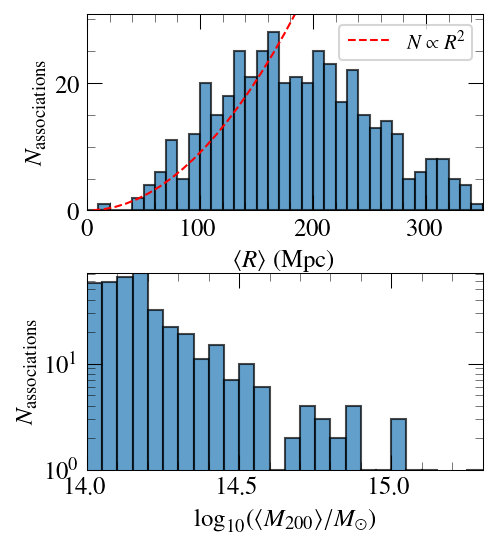

Distance statistics:
  Mean: 186.0 Mpc
  Median: 181.3 Mpc
  Min/Max: 19.3 / 377.2 Mpc

Mass statistics:
  Mean log10(M200): 14.21
  Median log10(M200): 14.15
  Min/Max log10(M200): 13.94 / 15.43


In [42]:
# Get style context
if USE_MNRAS_STYLE:
    style_context = plt.style.context(get_mplstyle_path(mnras_style))
else:
    from contextlib import nullcontext
    style_context = nullcontext()
    
def plot_distances_and_mass():
    if not clusters_available or len(clusters) == 0:
        print("No clusters available")
        return
    
    # Calculate mean distance for each cluster
    observer = np.array([500, 500, 500])
    mean_distances = []
    masses = []
    
    for cluster in clusters:
        # Get mass
        masses.append(cluster['mean_m200_mass'])
        
        if 'member_data' not in cluster:
            # Fall back to cluster center for distance
            dist = np.linalg.norm(cluster['center_xyz'] - observer)
            mean_distances.append(dist)
            continue
        
        member_data = cluster['member_data']
        
        # Try to get distance directly, or compute from positions
        if 'dist' in member_data:
            dist = np.mean(member_data['dist'])
        elif 'positions' in member_data:
            positions = member_data['positions']
            dists = np.linalg.norm(positions - observer, axis=1)
            dist = np.mean(dists)
        elif 'BoundSubhalo/CentreOfMass' in member_data:
            positions = member_data['BoundSubhalo/CentreOfMass']
            dists = np.linalg.norm(positions - observer, axis=1)
            dist = np.mean(dists)
        else:
            # Fall back to cluster center
            dist = np.linalg.norm(cluster['center_xyz'] - observer)
        
        mean_distances.append(dist)
    
    mean_distances = np.array(mean_distances)
    masses = np.array(masses)
    log_masses = np.log10(masses)
    
    with style_context:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.15, 3.5))
        
        # Top panel: Distance histogram
        n, bins, patches = ax1.hist(mean_distances, bins=np.arange(0, 510, 10),
                                    alpha=0.7, edgecolor='black')
        
        # Add R² scaling line (expected for uniform distribution in 3D)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        r_squared_line = bin_centers**2
        scaling_factor = 1./1100  # Adjust this to match your data
        r_squared_line *= scaling_factor
        ax1.plot(bin_centers, r_squared_line, 'r--', linewidth=1, label=r'$N \propto R^2$')
        
        ax1.set_xlabel(r'$\langle R \rangle$ (Mpc)')
        ax1.set_ylabel(r'$N_{\mathrm{associations}}$')
        ax1.set_ylim(0, 1.1 * np.max(n))
        ax1.set_xlim(0, 350)
        ax1.legend()
        
        # Bottom panel: Mass distribution
        mass_bins = np.arange(14,15.3,0.05)
        ax2.hist(log_masses, bins=mass_bins, alpha=0.7, edgecolor='black')
        
        ax2.set_xlabel(r'$\log_{10}(\langle M_{200} \rangle / M_{\odot})$')
        ax2.set_ylabel(r'$N_{\mathrm{associations}}$')
        ax2.set_xlim(14,15.3)
        ax2.set_yscale("log")

        plt.tight_layout(pad=0.1)
        plt.savefig("./plots/mean_distances.pdf")
        plt.show()
    
    # Print statistics
    print(f"Distance statistics:")
    print(f"  Mean: {np.mean(mean_distances):.1f} Mpc")
    print(f"  Median: {np.median(mean_distances):.1f} Mpc")
    print(f"  Min/Max: {np.min(mean_distances):.1f} / {np.max(mean_distances):.1f} Mpc")
    print(f"\nMass statistics:")
    print(f"  Mean log10(M200): {np.mean(log_masses):.2f}")
    print(f"  Median log10(M200): {np.median(log_masses):.2f}")
    print(f"  Min/Max log10(M200): {np.min(log_masses):.2f} / {np.max(log_masses):.2f}")

# Create the plot
plot_distances_and_mass()

## Export Posterior Association Catalog

Save the complete catalog to HDF5 with:
- Summary statistics for each association
- Full posterior member data
- Selection flags: `in_fiducial` and `in_strict` (non-exclusive boolean columns)
- New metadata including ambiguity scores, existence probabilities, and stability status

In [ ]:
# Cell: Export Complete Cluster Catalog with Quality Selections
import h5py
import numpy as np
import os

# Configuration
output_filename = "manticore_posterior_association_catalog.h5"
OUTPUT_DIR = os.path.dirname(CATALOG_PATH)

def passes_selection(cluster, selection_cuts, selection_name):
    """
    Check if a cluster passes a given selection.
    Returns True if it passes, False otherwise.
    """
    cuts = selection_cuts.get(selection_name, {})
    if not cuts:
        return True  # Raw - no cuts, everything passes
    
    # Extract values for comparison
    values = {
        'ambiguity_rate': cluster.get('ambiguity_rate', 0),
        'n_members': cluster.get('n_members', 0),
        'sigma_R': np.linalg.norm(cluster.get('position_std', [0, 0, 0])),
        'sigma_log_M': cluster.get('log10_m200_mass_std', 0),
    }
    
    for key, (lo, hi) in cuts.items():
        val = values.get(key, 0)
        if lo is not None and val < lo:
            return False
        if hi is not None and val > hi:
            return False
    return True

if len(clusters_raw) > 0:
    print(f"Processing {len(clusters_raw)} clusters...")
    
    # Get all property keys from first cluster's member_data
    if 'member_data' in clusters_raw[0]:
        property_keys = list(clusters_raw[0]['member_data'].keys())
    else:
        property_keys = []
    
    # Compute selection flags for all clusters (non-exclusive)
    in_fiducial = np.array([passes_selection(c, SELECTION_CUTS, 'Fiducial') for c in clusters_raw])
    in_strict = np.array([passes_selection(c, SELECTION_CUTS, 'Strict') for c in clusters_raw])
    
    # Print selection statistics
    print(f"\nSelection statistics:")
    print(f"  Total clusters (Raw): {len(clusters_raw)}")
    print(f"  In Fiducial: {np.sum(in_fiducial)} ({100*np.mean(in_fiducial):.1f}%)")
    print(f"  In Strict: {np.sum(in_strict)} ({100*np.mean(in_strict):.1f}%)")
    
    # Initialize storage for summary statistics
    summary_data = {}
    for key in property_keys:
        summary_data[key] = {'median': [], 'p25': [], 'p75': []}
    
    # Store association IDs and metadata
    association_ids = []
    n_members_list = []
    mean_m200_mass_list = []
    m200_mass_std_list = []
    log10_m200_mass_std_list = []
    center_xyz_list = []
    position_std_list = []
    axis_ratio_ba_list = []
    ambiguity_rate_list = []
    existence_prob_list = []
    status_list = []
    
    # Calculate summary statistics for each cluster
    for cluster in clusters_raw:
        association_ids.append(cluster['cluster_id'])
        n_members_list.append(cluster.get('n_members', 0))
        mean_m200_mass_list.append(cluster.get('mean_m200_mass', np.nan))
        m200_mass_std_list.append(cluster.get('m200_mass_std', np.nan))
        log10_m200_mass_std_list.append(cluster.get('log10_m200_mass_std', np.nan))
        center_xyz_list.append(cluster.get('center_xyz', [np.nan, np.nan, np.nan]))
        position_std_list.append(cluster.get('position_std', [np.nan, np.nan, np.nan]))
        axis_ratio_ba_list.append(cluster.get('axis_ratio_ba', np.nan))
        ambiguity_rate_list.append(cluster.get('ambiguity_rate', np.nan))
        existence_prob_list.append(cluster.get('existence_prob', np.nan))
        status_list.append(cluster.get('status', 'unknown'))
        
        if 'member_data' in cluster:
            for key in property_keys:
                if key not in cluster['member_data']:
                    # Handle missing keys
                    summary_data[key]['median'].append(np.nan)
                    summary_data[key]['p25'].append(np.nan)
                    summary_data[key]['p75'].append(np.nan)
                    continue
                    
                data = cluster['member_data'][key]
                
                if len(data.shape) == 1:
                    # 1D property - simple percentiles
                    summary_data[key]['median'].append(np.nanpercentile(data, 50))
                    summary_data[key]['p25'].append(np.nanpercentile(data, 25))
                    summary_data[key]['p75'].append(np.nanpercentile(data, 75))
                elif len(data.shape) == 2 and data.shape[1] == 3:
                    # 3D vector - percentiles per component
                    summary_data[key]['median'].append(np.nanpercentile(data, 50, axis=0))
                    summary_data[key]['p25'].append(np.nanpercentile(data, 25, axis=0))
                    summary_data[key]['p75'].append(np.nanpercentile(data, 75, axis=0))
                else:
                    # Other shapes - percentiles along first axis
                    summary_data[key]['median'].append(np.nanpercentile(data, 50, axis=0))
                    summary_data[key]['p25'].append(np.nanpercentile(data, 25, axis=0))
                    summary_data[key]['p75'].append(np.nanpercentile(data, 75, axis=0))
    
    # Convert summary lists to arrays
    for key in property_keys:
        for stat in ['median', 'p25', 'p75']:
            summary_data[key][stat] = np.array(summary_data[key][stat])
    
    # Convert metadata lists to arrays
    association_ids = np.array(association_ids)
    n_members = np.array(n_members_list)
    mean_m200_mass = np.array(mean_m200_mass_list)
    m200_mass_std = np.array(m200_mass_std_list)
    log10_m200_mass_std = np.array(log10_m200_mass_std_list)
    center_xyz = np.array(center_xyz_list)
    position_std = np.array(position_std_list)
    axis_ratio_ba = np.array(axis_ratio_ba_list)
    ambiguity_rate = np.array(ambiguity_rate_list)
    existence_prob = np.array(existence_prob_list)
    
    # Encode status as integers for HDF5
    status_encoding = {'stable': 2, 'tentative': 1, 'rare': 0, 'unknown': -1}
    status_encoded = np.array([status_encoding.get(s, -1) for s in status_list])
    
    # Save to HDF5
    output_path = os.path.join(OUTPUT_DIR, output_filename)
    
    with h5py.File(output_path, 'w') as f:
        # Metadata
        f.attrs['n_clusters'] = len(clusters_raw)
        f.attrs['n_fiducial'] = int(np.sum(in_fiducial))
        f.attrs['n_strict'] = int(np.sum(in_strict))
        f.attrs['total_properties'] = len(property_keys)
        f.attrs['status_encoding'] = 'stable=2, tentative=1, rare=0, unknown=-1'
        
        # Save selection cuts as metadata
        for sel_name, cuts in SELECTION_CUTS.items():
            if cuts:
                for param, (lo, hi) in cuts.items():
                    lo_str = str(lo) if lo is not None else 'None'
                    hi_str = str(hi) if hi is not None else 'None'
                    f.attrs[f'selection_{sel_name}_{param}'] = f'[{lo_str}, {hi_str}]'
        
        # Copy original metadata if available
        if 'metadata' in locals() and metadata is not None:
            for key, value in metadata.items():
                if isinstance(value, (int, float, str)):
                    f.attrs[f'original_{key}'] = value
                elif isinstance(value, (list, np.ndarray)):
                    try:
                        f.attrs[f'original_{key}'] = np.array(value)
                    except:
                        pass  # Skip complex types
        
        # Create summary group
        summary_grp = f.create_group('summary')
        
        # Save core metadata arrays
        summary_grp.create_dataset('association_id', data=association_ids)
        summary_grp['association_id'].attrs['description'] = 'Association/cluster ID for each row'
        
        summary_grp.create_dataset('in_fiducial', data=in_fiducial)
        summary_grp['in_fiducial'].attrs['description'] = 'True if passes Fiducial selection cuts'
        
        summary_grp.create_dataset('in_strict', data=in_strict)
        summary_grp['in_strict'].attrs['description'] = 'True if passes Strict selection cuts'
        
        summary_grp.create_dataset('n_members', data=n_members)
        summary_grp['n_members'].attrs['description'] = 'Number of members in each association'
        
        summary_grp.create_dataset('mean_m200_mass', data=mean_m200_mass)
        summary_grp['mean_m200_mass'].attrs['description'] = 'Mean M200 mass in Msol'
        
        summary_grp.create_dataset('m200_mass_std', data=m200_mass_std)
        summary_grp['m200_mass_std'].attrs['description'] = 'Standard deviation of M200 mass in Msol'
        
        summary_grp.create_dataset('log10_m200_mass_std', data=log10_m200_mass_std)
        summary_grp['log10_m200_mass_std'].attrs['description'] = 'Standard deviation of log10(M200/Msol)'
        
        summary_grp.create_dataset('center_xyz', data=center_xyz)
        summary_grp['center_xyz'].attrs['description'] = 'Mean position (x, y, z) in Mpc'
        
        summary_grp.create_dataset('position_std', data=position_std)
        summary_grp['position_std'].attrs['description'] = 'Position standard deviation per axis in Mpc'
        
        summary_grp.create_dataset('axis_ratio_ba', data=axis_ratio_ba)
        summary_grp['axis_ratio_ba'].attrs['description'] = 'Axis ratio b/a from PCA'
        
        summary_grp.create_dataset('ambiguity_rate', data=ambiguity_rate)
        summary_grp['ambiguity_rate'].attrs['description'] = 'Fraction of members with ambiguous cluster assignment'
        
        summary_grp.create_dataset('existence_prob', data=existence_prob)
        summary_grp['existence_prob'].attrs['description'] = 'Existence probability from HDBSCAN'
        
        summary_grp.create_dataset('status', data=status_encoded)
        summary_grp['status'].attrs['description'] = 'Stability status: stable=2, tentative=1, rare=0, unknown=-1'
        
        # Save summary statistics for each member property
        for key in property_keys:
            # Convert property name to HDF5-safe format
            dataset_name = key.replace('/', '_')
            
            # Get the shape of the data
            median_arr = summary_data[key]['median']
            
            if len(median_arr.shape) == 1:
                # Scalar property - create 2D array with 3 columns
                summary_array = np.column_stack([
                    summary_data[key]['median'],
                    summary_data[key]['p25'],
                    summary_data[key]['p75']
                ])
                
                ds = summary_grp.create_dataset(dataset_name, data=summary_array)
                ds.attrs['columns'] = ['median', 'p25', 'p75']
                ds.attrs['original_property'] = key
                
            elif len(median_arr.shape) == 2 and median_arr.shape[1] == 3:
                # 3D vector property - create 3D array (n_clusters, 3, 3)
                summary_array = np.stack([
                    summary_data[key]['median'],
                    summary_data[key]['p25'],
                    summary_data[key]['p75']
                ], axis=-1)
                
                ds = summary_grp.create_dataset(dataset_name, data=summary_array)
                ds.attrs['dimensions'] = ['cluster', 'xyz', 'statistic']
                ds.attrs['statistics'] = ['median', 'p25', 'p75']
                ds.attrs['original_property'] = key
            else:
                # Other multi-dimensional properties - store as separate datasets
                grp = summary_grp.create_group(dataset_name)
                grp.create_dataset('median', data=summary_data[key]['median'])
                grp.create_dataset('p25', data=summary_data[key]['p25'])
                grp.create_dataset('p75', data=summary_data[key]['p75'])
                grp.attrs['original_property'] = key
        
        # Create posterior group with full member data
        posterior_grp = f.create_group('posterior')
        
        for i, cluster in enumerate(clusters_raw):
            cluster_id = cluster['cluster_id']
            cluster_grp = posterior_grp.create_group(f'association_{cluster_id}')
            
            # Add cluster metadata as attributes
            cluster_grp.attrs['cluster_id'] = cluster_id
            cluster_grp.attrs['in_fiducial'] = bool(in_fiducial[i])
            cluster_grp.attrs['in_strict'] = bool(in_strict[i])
            cluster_grp.attrs['n_members'] = cluster.get('n_members', 0)
            cluster_grp.attrs['mean_m200_mass'] = cluster.get('mean_m200_mass', np.nan)
            cluster_grp.attrs['m200_mass_std'] = cluster.get('m200_mass_std', np.nan)
            cluster_grp.attrs['log10_m200_mass_std'] = cluster.get('log10_m200_mass_std', np.nan)
            cluster_grp.attrs['center_xyz'] = cluster.get('center_xyz', [np.nan, np.nan, np.nan])
            cluster_grp.attrs['position_std'] = cluster.get('position_std', [np.nan, np.nan, np.nan])
            cluster_grp.attrs['axis_ratio_ba'] = cluster.get('axis_ratio_ba', np.nan)
            cluster_grp.attrs['ambiguity_rate'] = cluster.get('ambiguity_rate', np.nan)
            cluster_grp.attrs['existence_prob'] = cluster.get('existence_prob', np.nan)
            cluster_grp.attrs['status'] = cluster.get('status', 'unknown')
            
            # Save all member properties
            if 'member_data' in cluster:
                for key in cluster['member_data'].keys():
                    dataset_name = key.replace('/', '_')
                    cluster_grp.create_dataset(dataset_name, data=cluster['member_data'][key])
        
        # Add cluster ID list for easy reference
        posterior_grp.attrs['cluster_ids'] = association_ids.tolist()
        posterior_grp.attrs['n_clusters'] = len(clusters_raw)
    
    print(f"\nSaved complete catalog to: {output_path}")
    print(f"Properties included: {len(property_keys)}")
    print(f"Associations saved: {len(clusters_raw)}")
    if property_keys:
        print(f"Sample properties: {property_keys[:5]}{'...' if len(property_keys) > 5 else ''}")
    
    # Summary statistics
    total_halos = sum([c.get('n_members', 0) for c in clusters_raw])
    print(f"\nSummary:")
    print(f"  Total halos in catalog: {total_halos}")
    print(f"  Associations: {len(clusters_raw)}")
    print(f"  In Fiducial: {np.sum(in_fiducial)}")
    print(f"  In Strict: {np.sum(in_strict)}")
    print(f"  File size: {os.path.getsize(output_path) / 1024**2:.2f} MB")
    
    print(f"\nFile structure:")
    print(f"  /summary/association_id : Array of cluster IDs")
    print(f"  /summary/in_fiducial : Boolean array for Fiducial selection")
    print(f"  /summary/in_strict : Boolean array for Strict selection")
    print(f"  /summary/n_members : Number of members per association")
    print(f"  /summary/ambiguity_rate : Ambiguity rate per association")
    print(f"  /summary/[properties] : {len(property_keys)} datasets with summary statistics")
    print(f"  /posterior/ : Contains {len(clusters_raw)} association groups with full member data")
    
    print(f"\nUsage example:")
    print(f"  with h5py.File('{output_filename}', 'r') as f:")
    print(f"      fiducial_mask = f['summary/in_fiducial'][:]")
    print(f"      strict_mask = f['summary/in_strict'][:]")
    print(f"      masses = f['summary/mean_m200_mass'][fiducial_mask]")

else:
    print("No cluster data available. Load data first.")